In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

SEED = 1672891
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Usando: cuda
GPU: NVIDIA GeForce RTX 5070


In [11]:
BASE_DIR = r"D:\Universidad\TFG\OASIS"
X_PATH = os.path.join(BASE_DIR, "X_av45_128x128x64.npy")
Y_PATH = os.path.join(BASE_DIR, "y_av45_128x128x64.npy")
META_PATH = os.path.join(BASE_DIR, "metadata_av45_128x128x64.csv")
BEST_MODEL_PATH = os.path.join(BASE_DIR, "best_cnn_av45_partial_sampler.pth")

X = np.load(X_PATH)
y = np.load(Y_PATH)
meta = pd.read_csv(META_PATH)

if X.ndim == 4:
    X = np.expand_dims(X, axis=1)

print("X:", X.shape)
print("y:", y.shape)
print("Distribución:", np.bincount(y))
meta.head()

X: (726, 1, 128, 128, 64)
y: (726,)
Distribución: [610 116]


,ruta_imagen,filename,OASISID,days_from_entry,tracer,label_binaria,CDRTOT_match,days_to_visit_match,days_diff_label
0,D:\Universidad\TFG\OASIS\av45\www.nitrc.org\ir...,sub-OAS30001_ses-d2430_acq-AV45_pet.nii.gz,OAS30001,2430,AV45,0,0.0,2181.0,249.0
1,D:\Universidad\TFG\OASIS\av45\www.nitrc.org\ir...,sub-OAS30002_ses-d2340_acq-AV45_pet.nii.gz,OAS30002,2340,AV45,0,0.0,2263.0,77.0
2,D:\Universidad\TFG\OASIS\av45\www.nitrc.org\ir...,sub-OAS30003_ses-d2682_acq-AV45_pet.nii.gz,OAS30003,2682,AV45,0,0.0,2630.0,52.0
3,D:\Universidad\TFG\OASIS\av45\www.nitrc.org\ir...,sub-OAS30003_ses-d3731_acq-AV45_pet.nii.gz,OAS30003,3731,AV45,0,0.0,3633.0,98.0
4,D:\Universidad\TFG\OASIS\av45\www.nitrc.org\ir...,sub-OAS30004_ses-d3457_acq-AV45_pet.nii.gz,OAS30004,3457,AV45,0,0.0,3458.0,1.0


## 1. Split train/validation/test por paciente

OASIS-3 es longitudinal, por lo que un mismo paciente puede tener varias imágenes PET. Para evitar fuga de información, la separación se hace por `OASISID`: todas las imágenes de un mismo paciente quedan solo en train, validation o test.

In [12]:
GROUP_COL = "OASISID"

if GROUP_COL not in meta.columns:
    raise ValueError(f"No encuentro la columna {GROUP_COL} en el metadata")

if len(meta) != len(X):
    raise ValueError(
        f"El metadata y X no tienen la misma longitud: len(meta)={len(meta)}, len(X)={len(X)}. "
        "Revisa que estés usando el metadata correspondiente al .npy cargado."
    )

groups = meta[GROUP_COL].astype(str).values

gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

trainval_idx, test_idx = next(gss_test.split(X, y, groups=groups))

X_trainval = X[trainval_idx]
y_trainval = y[trainval_idx]
groups_trainval = groups[trainval_idx]

X_test = X[test_idx]
y_test = y[test_idx]
groups_test = groups[test_idx]

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

train_idx_rel, val_idx_rel = next(gss_val.split(X_trainval, y_trainval, groups=groups_trainval))

X_train = X_trainval[train_idx_rel]
y_train = y_trainval[train_idx_rel]
groups_train = groups_trainval[train_idx_rel]

X_val = X_trainval[val_idx_rel]
y_val = y_trainval[val_idx_rel]
groups_val = groups_trainval[val_idx_rel]

print("\nNúmero de pacientes:")
print("Train:", len(set(groups_train)))
print("Val:", len(set(groups_val)))
print("Test:", len(set(groups_test)))

print("\nNúmero de imágenes y distribución de clases:")
print("Train:", X_train.shape, np.bincount(y_train))
print("Val:", X_val.shape, np.bincount(y_val))
print("Test:", X_test.shape, np.bincount(y_test))

if len(set(groups_train) & set(groups_val)) == 0 and len(set(groups_train) & set(groups_test)) == 0 and len(set(groups_val) & set(groups_test)) == 0:
    print("\nOK: no hay pacientes repetidos entre train, validation y test.")
else:
    print("\nATENCIÓN: hay fuga de pacientes entre conjuntos.")



Número de pacientes:
Train: 393
Val: 99
Test: 123

Número de imágenes y distribución de clases:
Train: (474, 1, 128, 128, 64) [408  66]
Val: (109, 1, 128, 128, 64) [90 19]
Test: (143, 1, 128, 128, 64) [112  31]

OK: no hay pacientes repetidos entre train, validation y test.


## 2. DataLoaders y estrategia de balanceo parcial

El dataset AV45 està desbalancejat, per això es fa servir un **sampler parcial** 70/30:

- 70% sans.
- 30% Alzheimer.

Això augmenta la presència de la clase minoritaria durant l'entrenament.


In [13]:
BALANCE_STRATEGY = "partial_sampler"  
BATCH_SIZE = 2


TARGET_RATIO = {
    0: 0.70,  
    1: 0.30   
}

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)

pin_memory = torch.cuda.is_available()
g = torch.Generator()
g.manual_seed(SEED)

print("Distribución train real:", np.bincount(y_train))
print("Estrategia:", BALANCE_STRATEGY)

if BALANCE_STRATEGY == "partial_sampler":
    class_counts = np.bincount(y_train)
    sample_weights = np.zeros(len(y_train), dtype=np.float32)

    for cls in [0, 1]:
        sample_weights[y_train == cls] = TARGET_RATIO[cls] / class_counts[cls]

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=g
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        pin_memory=pin_memory
    )

    print("Sampler parcial activado. Ratio objetivo:", TARGET_RATIO)
    criterion = nn.CrossEntropyLoss()

elif BALANCE_STRATEGY == "none":
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        pin_memory=pin_memory,
        generator=g
    )
    criterion = nn.CrossEntropyLoss()

elif BALANCE_STRATEGY == "focal_loss":
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        pin_memory=pin_memory,
        generator=g
    )

    class FocalLoss(nn.Module):
        def __init__(self, alpha=None, gamma=1.5):
            super().__init__()
            self.alpha = alpha
            self.gamma = gamma

        def forward(self, inputs, targets):
            ce_loss = F.cross_entropy(
                inputs,
                targets,
                reduction="none",
                weight=self.alpha
            )
            pt = torch.exp(-ce_loss)
            focal_loss = ((1 - pt) ** self.gamma) * ce_loss
            return focal_loss.mean()

    alpha = torch.tensor([1.0, 1.5], dtype=torch.float32).to(device)
    criterion = FocalLoss(alpha=alpha, gamma=1.5)
    print("Focal Loss activada con alpha=[1.0, 1.5], gamma=1.5")

else:
    raise ValueError(f"BALANCE_STRATEGY no reconocida: {BALANCE_STRATEGY}")

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=pin_memory
)

print("Criterion:", criterion)


Distribución train real: [408  66]
Estrategia: partial_sampler
Sampler parcial activado. Ratio objetivo: {0: 0.7, 1: 0.3}
Criterion: CrossEntropyLoss()


## 3. Model CNN 3D

In [14]:
class Small3DCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv3d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm3d(8),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.MaxPool3d(2),
            nn.Dropout3d(0.1),

            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(2),
            nn.Dropout3d(0.15),
        )

        self.pool = nn.AdaptiveAvgPool3d((4, 4, 4))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

model = Small3DCNN(num_classes=2).to(device)
print(model)

Small3DCNN(
  (features): Sequential(
    (0): Conv3d(1, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Dropout3d(p=0.1, inplace=False)
    (9): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (10): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Dropout3d(p=0.15, inplace=False)
  )
  (pool): AdaptiveAvgPool3d(output_size=(4, 4, 4))
  (cl

## 4. Train / Val

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        X_batch, y_batch = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(y_batch.detach().cpu().numpy())

    return calcular_metricas(running_loss / len(loader.dataset), all_labels, all_preds)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            X_batch, y_batch = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y_batch.detach().cpu().numpy())

    return calcular_metricas(running_loss / len(loader.dataset), all_labels, all_preds)


def calcular_metricas(loss, labels, preds):
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    return loss, acc, prec, rec, f1


def get_probabilities(model, loader, device):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for batch in loader:
            X_batch, y_batch = batch[0].to(device), batch[1]
            outputs = model(X_batch)
            p = torch.softmax(outputs, dim=1)[:, 1]
            probs.extend(p.cpu().numpy())
            labels.extend(y_batch.numpy())
    return np.array(probs), np.array(labels)


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Sa", "Alzheimer"]
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(
        cmap="Blues",
        colorbar=False,
        values_format="d",
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Predicció")
    ax.set_ylabel("Etiqueta real")

    plt.tight_layout()
    plt.show()


In [16]:
optimizer = optim.Adam(model.parameters(), lr=5e-4)

NUM_EPOCHS = 10
best_val_loss = float("inf")
history = {"train_loss": [], "train_f1": [], "val_loss": [], "val_f1": []}

for epoch in range(NUM_EPOCHS):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_metrics[0])
    history["train_f1"].append(train_metrics[4])
    history["val_loss"].append(val_metrics[0])
    history["val_f1"].append(val_metrics[4])

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train -> Loss: {train_metrics[0]:.4f} | Acc: {train_metrics[1]:.4f} | Prec: {train_metrics[2]:.4f} | Rec: {train_metrics[3]:.4f} | F1: {train_metrics[4]:.4f}")
    print(f"  Val   -> Loss: {val_metrics[0]:.4f} | Acc: {val_metrics[1]:.4f} | Prec: {val_metrics[2]:.4f} | Rec: {val_metrics[3]:.4f} | F1: {val_metrics[4]:.4f}")

    # Guardamos por val_loss para evitar premiar soluciones degeneradas de una sola clase.
    if val_metrics[0] < best_val_loss:
        best_val_loss = val_metrics[0]
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("  Modelo guardado")


Epoch 1/10
  Train -> Loss: 0.6571 | Acc: 0.6477 | Prec: 0.3000 | Rec: 0.0581 | F1: 0.0973
  Val   -> Loss: 0.6067 | Acc: 0.8257 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
  Modelo guardado
Epoch 2/10
  Train -> Loss: 0.6118 | Acc: 0.7152 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
  Val   -> Loss: 0.5380 | Acc: 0.8257 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
  Modelo guardado
Epoch 3/10
  Train -> Loss: 0.6167 | Acc: 0.7257 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
  Val   -> Loss: 0.4746 | Acc: 0.8257 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
  Modelo guardado
Epoch 4/10
  Train -> Loss: 0.6144 | Acc: 0.7278 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
  Val   -> Loss: 0.5484 | Acc: 0.8257 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
Epoch 5/10
  Train -> Loss: 0.6132 | Acc: 0.7152 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
  Val   -> Loss: 0.5118 | Acc: 0.8257 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
Epoch 6/10
  Train -> Loss: 0.6355 | Acc: 0.6941 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000


## 5. Ajuste de threshold

Probabilidades validación:
min: 0.16786359
max: 0.2811459
mean: 0.24160968
median: 0.24804026
Malla de thresholds en validación:


,threshold,val_accuracy,val_precision,val_recall,val_f1,val_f2,val_TN,val_FP,val_FN,val_TP,positivos_pred
0,0.10,0.174312,0.174312,1.000000,0.296875,0.513514,0,90,0,19,109
1,0.11,0.174312,0.174312,1.000000,0.296875,0.513514,0,90,0,19,109
2,0.12,0.174312,0.174312,1.000000,0.296875,0.513514,0,90,0,19,109
3,0.13,0.174312,0.174312,1.000000,0.296875,0.513514,0,90,0,19,109
4,0.14,0.174312,0.174312,1.000000,0.296875,0.513514,0,90,0,19,109
5,0.15,0.174312,0.174312,1.000000,0.296875,0.513514,0,90,0,19,109
6,0.16,0.174312,0.174312,1.000000,0.296875,0.513514,0,90,0,19,109
7,0.17,0.183486,0.175926,1.000000,0.299213,0.516304,1,89,0,19,108
8,0.18,0.192661,0.177570,1.000000,0.301587,0.519126,2,88,0,19,107
9,0.19,0.211009,0.180952,1.000000,0.306452,0.524862,4,86,0,19,105



Mejor threshold según F1 en validación:


,threshold,val_accuracy,val_precision,val_recall,val_f1,val_f2,val_TN,val_FP,val_FN,val_TP,positivos_pred
16,0.26,0.706422,0.30303,0.526316,0.384615,0.458716,67.0,23.0,9.0,10.0,33.0



Mejor threshold según F2 en validación:


,threshold,val_accuracy,val_precision,val_recall,val_f1,val_f2,val_TN,val_FP,val_FN,val_TP,positivos_pred
13,0.23,0.431193,0.220779,0.894737,0.354167,0.555556,30.0,60.0,2.0,17.0,77.0



Threshold elegido por F1: 0.26
Threshold elegido por F2: 0.23


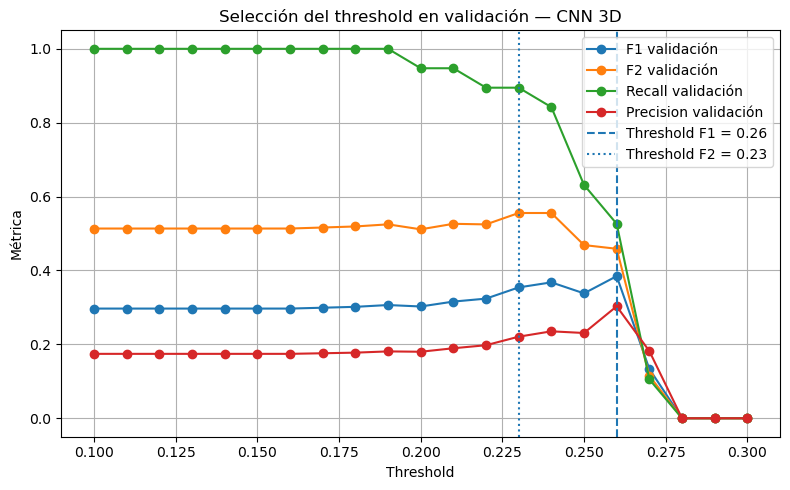

In [17]:
def fbeta_score_manual(precision, recall, beta=2):
    if precision == 0 and recall == 0:
        return 0.0
    return (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)


model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True))

val_probs, val_labels = get_probabilities(model, val_loader, device)

print("Probabilidades validación:")
print("min:", val_probs.min())
print("max:", val_probs.max())
print("mean:", val_probs.mean())
print("median:", np.median(val_probs))

thresholds = np.arange(0.10, 0.31, 0.01)
results = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)

    acc = accuracy_score(val_labels, preds)
    prec = precision_score(val_labels, preds, zero_division=0)
    rec = recall_score(val_labels, preds, zero_division=0)
    f1 = f1_score(val_labels, preds, zero_division=0)
    f2 = fbeta_score_manual(prec, rec, beta=2)

    tn, fp, fn, tp = confusion_matrix(val_labels, preds, labels=[0, 1]).ravel()

    results.append({
        "threshold": t,
        "val_accuracy": acc,
        "val_precision": prec,
        "val_recall": rec,
        "val_f1": f1,
        "val_f2": f2,
        "val_TN": tn,
        "val_FP": fp,
        "val_FN": fn,
        "val_TP": tp,
        "positivos_pred": preds.sum()
    })

df_thresholds = pd.DataFrame(results)

print("Malla de thresholds en validación:")
display(df_thresholds)

# Elegir mejor threshold por F1 y por F2, usando SOLO validación
best_row_f1 = df_thresholds.sort_values(
    by=["val_f1", "val_recall", "val_precision"],
    ascending=False
).iloc[0]

best_row_f2 = df_thresholds.sort_values(
    by=["val_f2", "val_recall", "val_precision"],
    ascending=False
).iloc[0]

best_threshold_f1 = float(best_row_f1["threshold"])
best_threshold_f2 = float(best_row_f2["threshold"])

print("\nMejor threshold según F1 en validación:")
display(best_row_f1.to_frame().T)

print("\nMejor threshold según F2 en validación:")
display(best_row_f2.to_frame().T)

print(f"\nThreshold elegido por F1: {best_threshold_f1:.2f}")
print(f"Threshold elegido por F2: {best_threshold_f2:.2f}")

# Gráfico comparativo
plt.figure(figsize=(8, 5))
plt.plot(df_thresholds["threshold"], df_thresholds["val_f1"], marker="o", label="F1 validación")
plt.plot(df_thresholds["threshold"], df_thresholds["val_f2"], marker="o", label="F2 validación")
plt.plot(df_thresholds["threshold"], df_thresholds["val_recall"], marker="o", label="Recall validación")
plt.plot(df_thresholds["threshold"], df_thresholds["val_precision"], marker="o", label="Precision validación")

plt.axvline(best_threshold_f1, linestyle="--", label=f"Threshold F1 = {best_threshold_f1:.2f}")
plt.axvline(best_threshold_f2, linestyle=":", label=f"Threshold F2 = {best_threshold_f2:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Selección del threshold en validación — CNN 3D")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Test

RESULTADOS TEST — threshold elegido por F1 en validación
Threshold F1: 0.2599999999999999
              precision    recall  f1-score   support

        Sano       0.83      0.82      0.83       112
   Alzheimer       0.38      0.39      0.38        31

    accuracy                           0.73       143
   macro avg       0.60      0.60      0.60       143
weighted avg       0.73      0.73      0.73       143

F2-score TEST usando threshold F1: 0.3846


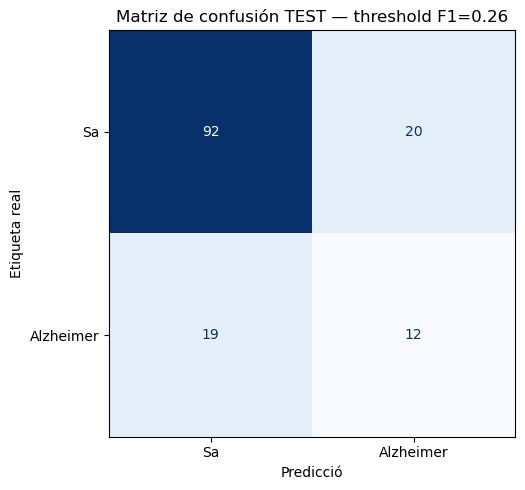


RESULTADOS TEST — threshold elegido por F2 en validación
Threshold F2: 0.22999999999999995
              precision    recall  f1-score   support

          Sa       0.86      0.32      0.47       112
   Alzheimer       0.25      0.81      0.38        31

    accuracy                           0.43       143
   macro avg       0.55      0.56      0.42       143
weighted avg       0.72      0.43      0.45       143

F2-score TEST usando threshold F2: 0.5556


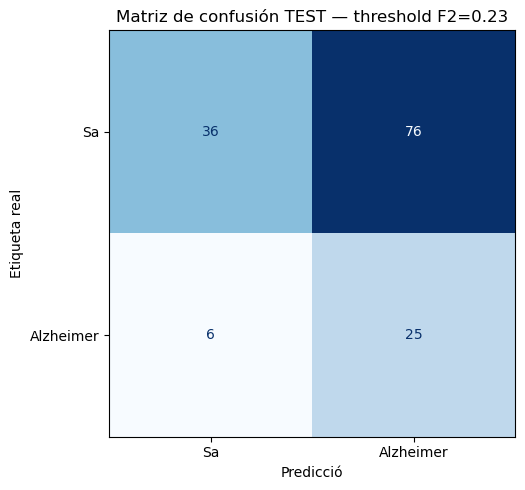

,modelo,criterio_threshold,threshold,accuracy,precision_alzheimer,recall_alzheimer,f1_alzheimer,f2_alzheimer,TN,FP,FN,TP
0,CNN 3D,Mejor F1 en validación,0.26,0.727273,0.375000,0.387097,0.380952,0.384615,92,20,19,12
1,CNN 3D,Mejor F2 en validación,0.23,0.426573,0.247525,0.806452,0.378788,0.555556,36,76,6,25


In [ ]:
from sklearn.metrics import classification_report, fbeta_score

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True))

test_probs, test_labels = get_probabilities(model, test_loader, device)

test_preds_f1 = (test_probs >= best_threshold_f1).astype(int)
test_preds_f2 = (test_probs >= best_threshold_f2).astype(int)
test_preds_05 = (test_probs >= 0.5).astype(int)

print("=" * 80)
print("RESULTADOS TEST — threshold elegido por F1 en validación")
print("=" * 80)
print("Threshold F1:", best_threshold_f1)
print(classification_report(
    test_labels,
    test_preds_f1,
    target_names=["Sano", "Alzheimer"],
    zero_division=0
))

f2_test_f1 = fbeta_score(test_labels, test_preds_f1, beta=2, zero_division=0)
print(f"F2-score TEST usando threshold F1: {f2_test_f1:.4f}")

plot_confusion(
    test_labels,
    test_preds_f1,
    f"Matriz de confusión TEST — threshold F1={best_threshold_f1:.2f}"
)


print("\n" + "=" * 80)
print("RESULTADOS TEST — threshold elegido por F2 en validación")
print("=" * 80)
print("Threshold F2:", best_threshold_f2)
print(classification_report(
    test_labels,
    test_preds_f2,
    target_names=["Sa", "Alzheimer"],
    zero_division=0
))

f2_test_f2 = fbeta_score(test_labels, test_preds_f2, beta=2, zero_division=0)
print(f"F2-score TEST usando threshold F2: {f2_test_f2:.4f}")

plot_confusion(
    test_labels,
    test_preds_f2,
    f"Matriz de confusión TEST — threshold F2={best_threshold_f2:.2f}"
)




def metricas_test(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_alzheimer": precision_score(y_true, y_pred, zero_division=0),
        "recall_alzheimer": recall_score(y_true, y_pred, zero_division=0),
        "f1_alzheimer": f1_score(y_true, y_pred, zero_division=0),
        "f2_alzheimer": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


df_resultados_test = pd.DataFrame([
    {
        "modelo": "CNN 3D",
        "criterio_threshold": "Mejor F1 en validación",
        "threshold": best_threshold_f1,
        **metricas_test(test_labels, test_preds_f1)
    },
    {
        "modelo": "CNN 3D",
        "criterio_threshold": "Mejor F2 en validación",
        "threshold": best_threshold_f2,
        **metricas_test(test_labels, test_preds_f2)
    }
])

display(df_resultados_test)